# Module 07 — Hyperparameter Search

Tuning is the part of modelling with the worst effort-to-value ratio. It is
also the part that feels most like progress, which is why teams spend weeks on
it while a leakage bug or a wrong metric sits untouched.

The useful skill is not "how do I run a grid search" — it is **knowing how much
tuning is available to be won on this problem, spending an appropriate budget,
and stopping.**

### Learning objectives

1. Choose between grid, random, halving and Bayesian search on the basis of
   budget and search-space shape.
2. Explain why random search beats grid search in high dimensions.
3. Use `cv_results_` as a diagnostic, not just a leaderboard.
4. Search over *model families*, not just hyperparameters.
5. Recognise when you are overfitting the validation set.
6. Know the two or three parameters that matter per model family, and ignore
   the rest.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style, summarize_cv

set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

In [2]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])

prep = ColumnTransformer(
    [
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string", "category"])),
    ]
)
cv = StratifiedKFold(5, shuffle=True, random_state=0)

## 1. Before you tune: how much is there to win?

Run this diagnostic first, every time. Fit the model at its defaults and at a
handful of deliberately extreme settings. The spread tells you the size of the
prize.

In [3]:
from sklearn.model_selection import cross_val_score

probe = {
    "default": HistGradientBoostingClassifier(random_state=0),
    "very shallow": HistGradientBoostingClassifier(random_state=0, max_leaf_nodes=3, learning_rate=0.05, max_iter=400),
    "very deep": HistGradientBoostingClassifier(random_state=0, max_leaf_nodes=255, min_samples_leaf=1, max_iter=400, early_stopping=False),
    "heavy regularisation": HistGradientBoostingClassifier(random_state=0, l2_regularization=10.0, max_leaf_nodes=8, learning_rate=0.03, max_iter=500),
    "tiny learning rate": HistGradientBoostingClassifier(random_state=0, learning_rate=0.005, max_iter=1500),
}
spread = pd.Series(
    {k: cross_val_score(Pipeline([("prep", prep), ("clf", v)]), X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
     for k, v in probe.items()}
).sort_values(ascending=False).round(4)
print(spread.to_string())
print(f"\nspread between best and worst extreme: {spread.max() - spread.min():.4f}")

very shallow            0.7695
heavy regularisation    0.7646
tiny learning rate      0.7562
default                 0.7514
very deep               0.7332

spread between best and worst extreme: 0.0363


Compare that spread against the noise floor you measured in Module 04
(≈ ±0.013 for this problem). If deliberately absurd settings only move the
score by a couple of noise-floor widths, **there is no tuning prize here** and
your effort belongs in features, data or the problem framing instead.

> 💼 **Consulting lens.** This diagnostic takes ninety seconds and reframes an
> entire workstream. "We ran a 500-point search and gained 0.004 AUC, which is
> inside the measurement noise" is a far more valuable finding to report than
> a marginally better model — and it redirects the budget to something that
> can actually move the outcome.

## 2. Grid search

Exhaustive over a Cartesian product. Cost is the product of the list lengths,
times folds. It explodes: 4 × 4 × 4 × 5 folds = 320 fits.

Use it when the space is small and low-dimensional, or when you need to be
able to say you searched exhaustively (which is sometimes a governance
requirement).

In [4]:
from time import perf_counter

from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(random_state=0, early_stopping=True))])

grid = {
    "clf__learning_rate": [0.03, 0.1],
    "clf__max_leaf_nodes": [8, 31],
    "clf__min_samples_leaf": [20, 100],
    "clf__l2_regularization": [0.0, 1.0],
}

t0 = perf_counter()
gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1, return_train_score=True).fit(X, y)
grid_time = perf_counter() - t0

print(f"{np.prod([len(v) for v in grid.values()])} candidates × 5 folds = "
      f"{np.prod([len(v) for v in grid.values()]) * 5} fits in {grid_time:.1f}s")
print(f"best score  : {gs.best_score_:.4f}")
print(f"best params : {gs.best_params_}")
summarize_cv(gs.cv_results_, top=5)

16 candidates × 5 folds = 80 fits in 20.1s
best score  : 0.7713
best params : {'clf__l2_regularization': 1.0, 'clf__learning_rate': 0.03, 'clf__max_leaf_nodes': 8, 'clf__min_samples_leaf': 20}


,params,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,"{'clf__l2_regularization': 1.0, 'clf__learning...",0.771342,0.008225,0.397849,1
1,"{'clf__l2_regularization': 1.0, 'clf__learning...",0.770990,0.008248,0.408059,2
2,"{'clf__l2_regularization': 0.0, 'clf__learning...",0.770621,0.008704,0.387638,3
3,"{'clf__l2_regularization': 0.0, 'clf__learning...",0.770613,0.008293,0.409264,4
4,"{'clf__l2_regularization': 1.0, 'clf__learning...",0.769768,0.008678,0.242963,5


## 3. Random search, and why it wins

The argument (Bergstra & Bengio, 2012) is geometric, not statistical. Suppose
only one of your four hyperparameters actually matters. A 4×4×4×4 grid tries
just **four distinct values** of that parameter — the other 252 fits are
duplicates from its point of view. A random search of 256 draws tries **256
distinct values** of it.

The more irrelevant dimensions your space has — and you never know in advance
which are irrelevant — the bigger the advantage.

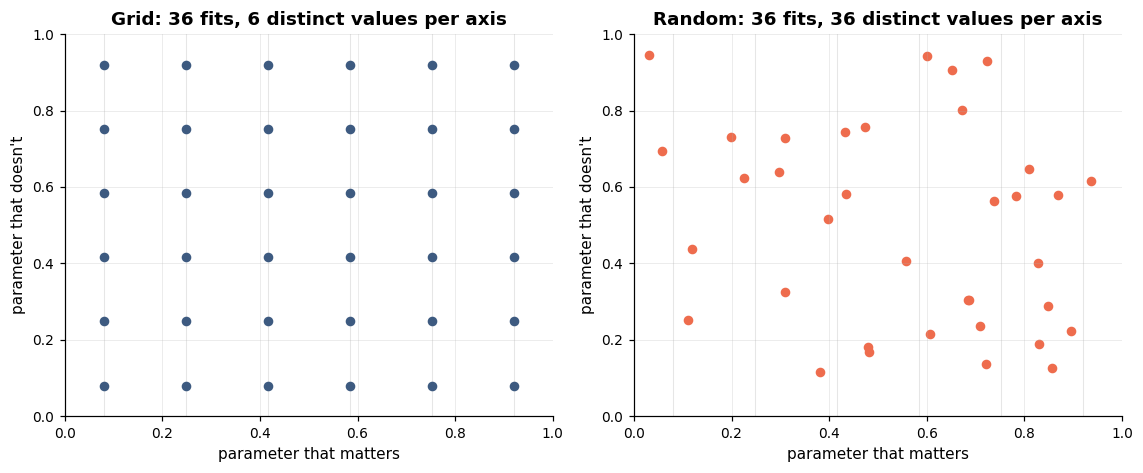

In [5]:
# The picture that makes it obvious.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
g = np.linspace(0.08, 0.92, 6)
gx, gy = np.meshgrid(g, g)
axes[0].scatter(gx.ravel(), gy.ravel(), s=28, color="#3d5a80")
axes[0].set_title("Grid: 36 fits, 6 distinct values per axis")
r = np.random.default_rng(3).uniform(0.03, 0.97, size=(36, 2))
axes[1].scatter(r[:, 0], r[:, 1], s=28, color="#ee6c4d")
axes[1].set_title("Random: 36 fits, 36 distinct values per axis")
for ax in axes:
    for x in g:
        ax.axvline(x, color="0.9", lw=0.7, zorder=0)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="parameter that matters", ylabel="parameter that doesn't")
plt.tight_layout()

In [6]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV

# Distributions, not lists. `loguniform` for anything that spans orders of
# magnitude (learning rates, regularisation strengths) -- a uniform draw over
# [1e-4, 1e0] puts 90% of its mass above 0.1, which is almost never what you meant.
dist = {
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__max_leaf_nodes": randint(4, 64),
    "clf__min_samples_leaf": randint(10, 300),
    "clf__l2_regularization": loguniform(1e-4, 10),
    "clf__max_features": uniform(0.4, 0.6),
}

t0 = perf_counter()
rs = RandomizedSearchCV(pipe, dist, n_iter=40, cv=cv, scoring="roc_auc",
                        random_state=0, n_jobs=-1, return_train_score=True).fit(X, y)
rand_time = perf_counter() - t0

print(f"grid   : {gs.best_score_:.4f} in {grid_time:5.1f}s over {len(gs.cv_results_['params'])} candidates")
print(f"random : {rs.best_score_:.4f} in {rand_time:5.1f}s over {len(rs.cv_results_['params'])} candidates")
print(f"\nbest random params: { {k: round(v, 4) if isinstance(v, float) else v for k, v in rs.best_params_.items()} }")

grid   : 0.7713 in  20.1s over 16 candidates
random : 0.7723 in  55.2s over 40 candidates

best random params: {'clf__l2_regularization': np.float64(0.0021), 'clf__learning_rate': np.float64(0.0593), 'clf__max_features': np.float64(0.4564), 'clf__max_leaf_nodes': 5, 'clf__min_samples_leaf': 46}


## 4. Successive halving: spend budget where it is earning

Halving search starts every candidate with a small "resource" (usually a
fraction of the training rows), keeps the best `1/factor` of them, multiplies
the resource, and repeats. Bad candidates are eliminated cheaply.

It is still marked experimental, so the import needs an explicit enable.

In [7]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

t0 = perf_counter()
hs = HalvingRandomSearchCV(
    pipe, dist, n_candidates=120, factor=3, resource="n_samples",
    min_resources=1200, cv=cv, scoring="roc_auc", random_state=0, n_jobs=-1,
).fit(X, y)
halv_time = perf_counter() - t0

print(f"halving: {hs.best_score_:.4f} in {halv_time:.1f}s, "
      f"{len(hs.cv_results_['params'])} candidate-evaluations across {hs.n_iterations_} rounds")

rounds = pd.DataFrame(hs.cv_results_).groupby("iter").agg(
    n_candidates=("params", "size"),
    n_resources=("n_resources", "first"),
    best_score=("mean_test_score", "max"),
).round(4)
rounds

halving: 0.7698 in 82.8s, 174 candidate-evaluations across 3 rounds


,n_candidates,n_resources,best_score
iter,,,
0,120,1200,0.7831
1,40,3600,0.7625
2,14,10800,0.7698


Read the table as a budget story: round 0 evaluates 120 candidates on 1,200
rows each (cheap), and each round triples the data while keeping a third of
the survivors. Total cost is far below evaluating 120 candidates at full size.

Look at the `best_score` column going *down* from round 0 to round 1. Round 0
scored 120 candidates on 1,200 rows each; the best of 120 noisy small-sample
estimates is an inflated number, for exactly the reason section 8 is about.
The later rounds have fewer candidates and more data, so their scores are more
honest. **Never read round 0's best score as a performance estimate** — it is
a screening statistic.

**The assumption to check:** halving requires that performance at a small
resource *ranks* candidates similarly to performance at full resource. That is
usually true and occasionally badly false — notably when some configurations
only start working once they have enough data (deep models, high-cardinality
categorical encodings). If your `min_resources` is very small, verify the
top few survivors against a full-resource evaluation before trusting the
ranking.

In [8]:
summary = pd.DataFrame([
    {"strategy": "GridSearchCV", "best": round(gs.best_score_, 4), "seconds": round(grid_time, 1), "candidates": len(gs.cv_results_["params"])},
    {"strategy": "RandomizedSearchCV", "best": round(rs.best_score_, 4), "seconds": round(rand_time, 1), "candidates": len(rs.cv_results_["params"])},
    {"strategy": "HalvingRandomSearchCV", "best": round(hs.best_score_, 4), "seconds": round(halv_time, 1), "candidates": 120},
]).set_index("strategy")
summary

,best,seconds,candidates
strategy,,,
GridSearchCV,0.7713,20.1,16
RandomizedSearchCV,0.7723,55.2,40
HalvingRandomSearchCV,0.7698,82.8,120


## 5. Bayesian optimisation with Optuna

Grid and random search are *memoryless* — evaluation 40 is drawn without
reference to evaluations 1–39. Bayesian methods build a surrogate model of
the objective and sample where the expected improvement is highest.

The payoff is largest when each evaluation is expensive and the budget is
small (tens, not thousands). Optuna is the pragmatic choice; it integrates
with sklearn in about ten lines.

In [9]:
import logging

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 4, 64),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 300),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
        "max_features": trial.suggest_float("max_features", 0.4, 1.0),
    }
    est = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(random_state=0, early_stopping=True, **params))])
    return cross_val_score(est, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()


t0 = perf_counter()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=40, show_progress_bar=False)
opt_time = perf_counter() - t0

print(f"optuna : {study.best_value:.4f} in {opt_time:.1f}s over 40 trials")
print(f"random : {rs.best_score_:.4f} in {rand_time:.1f}s over 40 trials")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


optuna : 0.7718 in 54.4s over 40 trials
random : 0.7723 in 55.2s over 40 trials


,importance
max_leaf_nodes,0.510
learning_rate,0.449
max_features,0.020
min_samples_leaf,0.019
l2_regularization,0.001


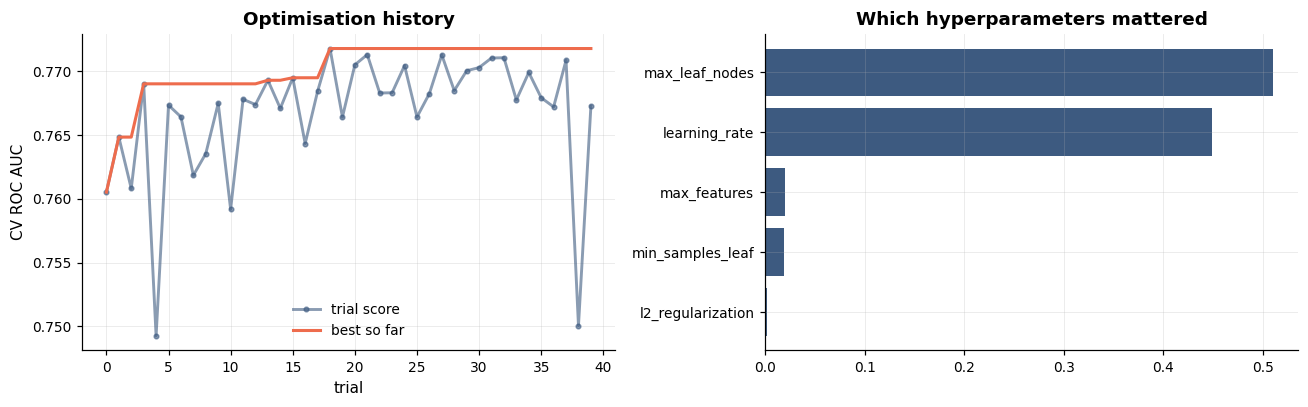

In [10]:
# Optuna's real value is often the *analysis*, not the extra 0.001.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
vals = np.array([t.value for t in study.trials if t.value is not None])
axes[0].plot(vals, "o-", ms=3, alpha=0.6, label="trial score")
axes[0].plot(np.maximum.accumulate(vals), lw=2, label="best so far")
axes[0].set(xlabel="trial", ylabel="CV ROC AUC", title="Optimisation history")
axes[0].legend()

imp = optuna.importance.get_param_importances(study)
axes[1].barh(list(imp)[::-1], list(imp.values())[::-1], color="#3d5a80")
axes[1].set_title("Which hyperparameters mattered")
plt.tight_layout()
pd.Series(imp, name="importance").round(3).to_frame()

That right-hand chart is the deliverable. It says which knobs are worth
documenting, which can be frozen at defaults, and where a future re-tune
should spend its budget.

## 6. Searching over model families

`param_grid` accepts a **list of dicts**, each defining an independent region
of the space. Combined with `"passthrough"`, this lets one search compare
genuinely different pipelines.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

family_pipe = Pipeline([
    ("prep", prep),
    ("select", "passthrough"),
    ("clf", LogisticRegression(max_iter=4000)),
])

family_grid = [
    {
        "clf": [LogisticRegression(max_iter=4000)],
        "clf__C": [0.01, 0.1, 1.0],
        "clf__class_weight": [None, "balanced"],
        "select": ["passthrough", SelectKBest(f_classif, k=20)],
    },
    {
        "clf": [RandomForestClassifier(random_state=0, n_jobs=-1)],
        "clf__n_estimators": [300],
        "clf__min_samples_leaf": [5, 25],
        "clf__max_features": ["sqrt", 0.5],
    },
    {
        "clf": [HistGradientBoostingClassifier(random_state=0, early_stopping=True)],
        "clf__learning_rate": [0.03, 0.1],
        "clf__max_leaf_nodes": [8, 31],
    },
]

fam = GridSearchCV(family_pipe, family_grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X, y)
print(f"winner: {type(fam.best_estimator_.named_steps['clf']).__name__}  ->  {fam.best_score_:.4f}\n")

res = pd.DataFrame(fam.cv_results_)
res["family"] = res["param_clf"].map(lambda e: type(e).__name__)
res.groupby("family").agg(best=("mean_test_score", "max"), median=("mean_test_score", "median"),
                          worst=("mean_test_score", "min"), n=("mean_test_score", "size")).round(4)

winner: LogisticRegression  ->  0.7761



,best,median,worst,n
family,,,,
HistGradientBoostingClassifier,0.7706,0.7672,0.7589,4
LogisticRegression,0.7761,0.7747,0.7735,12
RandomForestClassifier,0.7673,0.7649,0.7595,4


The `median` column is more informative than `best`. A family whose *median*
configuration is strong is robust to your not having tuned it perfectly; a
family that only wins at one lucky corner of the space probably got there by
overfitting the folds.

## 7. Reading `cv_results_` as a diagnostic

Three questions to ask of any completed search.

In [12]:
r = pd.DataFrame(rs.cv_results_)

# (a) Is the best score meaningfully above the rest, or is the leaderboard flat?
top = r.nlargest(10, "mean_test_score")[["mean_test_score", "std_test_score"]]
print(f"best      : {top.mean_test_score.iloc[0]:.4f}")
print(f"10th best : {top.mean_test_score.iloc[-1]:.4f}")
print(f"gap       : {top.mean_test_score.iloc[0] - top.mean_test_score.iloc[-1]:.4f}")
print(f"typical fold-to-fold std among the top 10: {top.std_test_score.mean():.4f}")

best      : 0.7723
10th best : 0.7684
gap       : 0.0038
typical fold-to-fold std among the top 10: 0.0086


In [13]:
# (b) Are the best values at the EDGE of the range you searched?
for p in ["clf__learning_rate", "clf__max_leaf_nodes", "clf__min_samples_leaf", "clf__l2_regularization"]:
    vals = r[f"param_{p}"].astype(float)
    best_v = float(rs.best_params_[p])
    lo, hi = vals.min(), vals.max()
    edge = "  <-- AT EDGE, widen the range" if (best_v <= lo * 1.05 or best_v >= hi * 0.95) else ""
    print(f"{p:<28} searched [{lo:.4g}, {hi:.4g}]  best {best_v:.4g}{edge}")

clf__learning_rate           searched [0.01136, 0.2952]  best 0.05928
clf__max_leaf_nodes          searched [4, 61]  best 5
clf__min_samples_leaf        searched [13, 298]  best 46
clf__l2_regularization       searched [0.0001242, 5.233]  best 0.002123


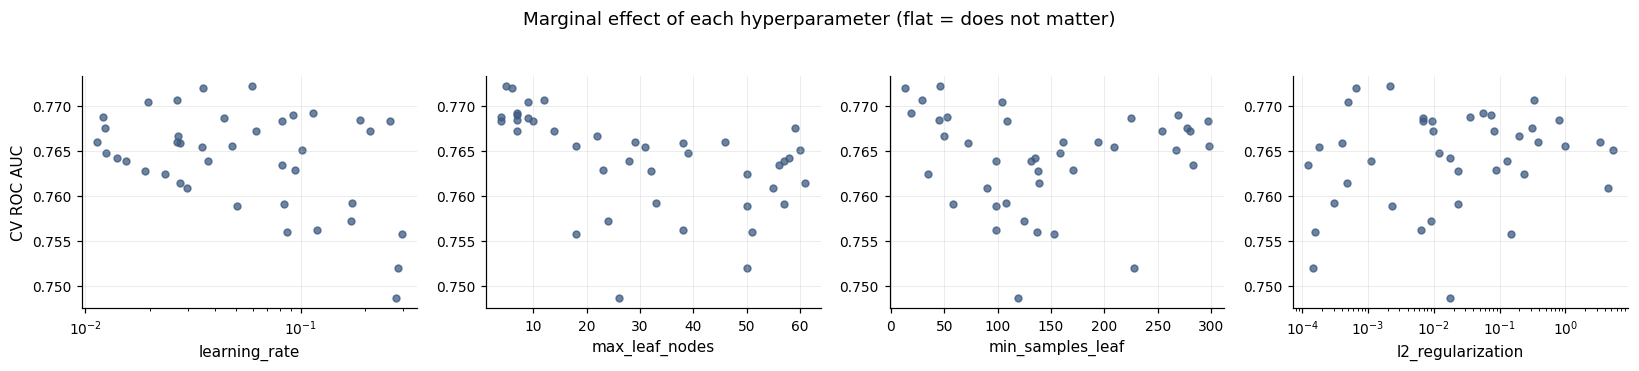

In [14]:
# (c) Where in the space are the good scores? A parallel view beats a table.
plot_cols = ["clf__learning_rate", "clf__max_leaf_nodes", "clf__min_samples_leaf", "clf__l2_regularization"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, p in zip(axes, plot_cols):
    ax.scatter(r[f"param_{p}"].astype(float), r["mean_test_score"], s=20, alpha=0.75, color="#3d5a80")
    ax.set(xlabel=p.replace("clf__", ""), ylabel="CV ROC AUC" if ax is axes[0] else "")
    if "rate" in p or "regular" in p:
        ax.set_xscale("log")
fig.suptitle("Marginal effect of each hyperparameter (flat = does not matter)", y=1.04)
plt.tight_layout()

## 8. Overfitting the validation set

Every candidate you evaluate is another chance for one to look good by
accident. With enough candidates, `best_score_` is the maximum of many noisy
draws — and the maximum of noise is biased upward.

Here is that bias, measured, on **data with no signal at all**.

,best_cv_score
n_candidates,
1,0.5465
5,0.5552
20,0.5616
60,0.5674
150,0.5892


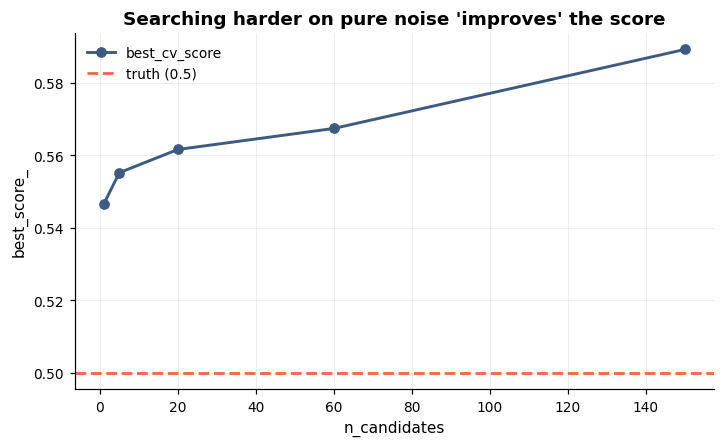

In [15]:
X_null = pd.DataFrame(rng.normal(size=(600, 20)), columns=[f"f{i}" for i in range(20)])
y_null = pd.Series(rng.integers(0, 2, 600))

rows = []
for n_iter in [1, 5, 20, 60, 150]:
    s = RandomizedSearchCV(
        RandomForestClassifier(random_state=0, n_jobs=1),
        {"n_estimators": randint(20, 200), "max_depth": randint(2, 20),
         "min_samples_leaf": randint(1, 40), "max_features": uniform(0.1, 0.9)},
        n_iter=n_iter, cv=5, scoring="roc_auc", random_state=1, n_jobs=-1,
    ).fit(X_null, y_null)
    rows.append({"n_candidates": n_iter, "best_cv_score": round(s.best_score_, 4)})

null_bias = pd.DataFrame(rows).set_index("n_candidates")
ax = null_bias.plot(marker="o", legend=False)
ax.axhline(0.5, ls="--", color="#ee6c4d", label="truth (0.5)")
ax.set(ylabel="best_score_", title="Searching harder on pure noise 'improves' the score")
ax.legend()
null_bias

The data contains nothing. The truth is 0.500. Yet `best_score_` climbs
steadily with the size of the search. **`best_score_` is not an estimate of
generalisation performance; it is a selected maximum.**

Three defences, in increasing order of cost:

1. **A never-touched holdout.** Split it off first, score it once, at the end.
   Cheap and effective, *if the discipline holds*.
2. **Nested CV** (Module 04). Unbiased, `n_outer ×` the cost.
3. **Smaller searches.** The most underrated option. If the top ten candidates
   are within the noise floor of each other, you are choosing between
   equivalent models and the search size was excessive.

## 9. What to tune, by model family

The 80/20, from practice. Everything not listed can usually stay at its
default.

| Family | Tune first | Tune second | Rarely worth it |
|---|---|---|---|
| **Logistic / Ridge / Lasso** | `C` or `alpha` | `class_weight`, `penalty` | `solver`, `tol` |
| **SVM (RBF)** | `C`, `gamma` (jointly, log scale) | `class_weight` | `kernel`, `degree` |
| **Random Forest** | `max_features`, `min_samples_leaf` | `n_estimators` (more is never worse, only slower) | `criterion`, `max_depth` |
| **HistGradientBoosting** | `learning_rate` × `max_iter` (coupled) | `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization` | `max_bins` |
| **XGBoost / LightGBM** | `learning_rate`, `num_leaves`/`max_depth` | `subsample`, `colsample_bytree`, `min_child_weight`, `reg_lambda` | most of the rest |
| **k-NN** | `n_neighbors`, `weights` | `metric`, `p` | `algorithm`, `leaf_size` |

Two rules that save more time than any search strategy:

- **`learning_rate` and `n_estimators` are one parameter, not two.** Halve the
  rate and you must roughly double the trees. Fix a small rate, turn on early
  stopping, and tune the rest.
- **`n_estimators` in a random forest is not a tuning parameter.** More trees
  monotonically reduce variance; pick the largest you can afford and stop
  thinking about it. (This is *not* true of boosting, where more trees
  eventually overfit.)

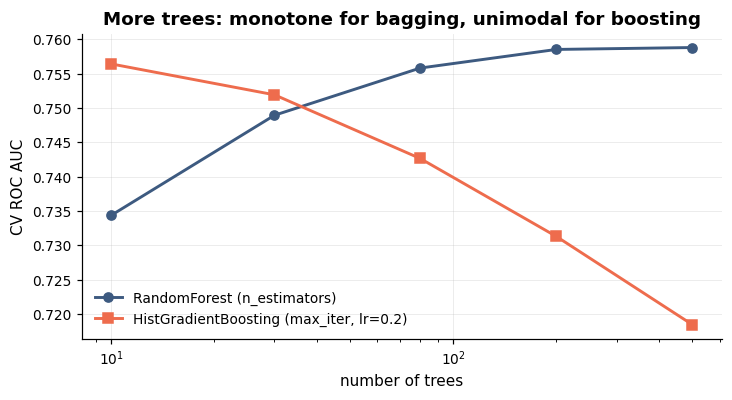

In [16]:
# Demonstrating the second rule.
from sklearn.model_selection import validation_curve

n_trees = [10, 30, 80, 200, 500]
tr_rf, te_rf = validation_curve(RandomForestClassifier(random_state=0, min_samples_leaf=5, n_jobs=-1),
                                X.select_dtypes(np.number).fillna(0), y,
                                param_name="n_estimators", param_range=n_trees, cv=3, scoring="roc_auc", n_jobs=-1)
tr_gb, te_gb = validation_curve(HistGradientBoostingClassifier(random_state=0, learning_rate=0.2, early_stopping=False),
                                X.select_dtypes(np.number).fillna(0), y,
                                param_name="max_iter", param_range=n_trees, cv=3, scoring="roc_auc", n_jobs=-1)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(n_trees, te_rf.mean(1), marker="o", label="RandomForest (n_estimators)")
ax.plot(n_trees, te_gb.mean(1), marker="s", label="HistGradientBoosting (max_iter, lr=0.2)")
ax.set(xscale="log", xlabel="number of trees", ylabel="CV ROC AUC",
       title="More trees: monotone for bagging, unimodal for boosting")
ax.legend()

## 10. Practical mechanics

A handful of parameters on the search objects themselves that save real pain.

In [17]:
from sklearn.metrics import make_scorer, roc_auc_score

# `refit` with multiple metrics: pick the winner by one metric, but record all.
multi = GridSearchCV(
    pipe,
    {"clf__learning_rate": [0.05, 0.15], "clf__max_leaf_nodes": [8, 31]},
    cv=cv,
    scoring={"auc": "roc_auc", "ap": "average_precision", "brier": "neg_brier_score"},
    refit="ap",                       # choose on average precision
    n_jobs=-1,
).fit(X, y)
print("chosen by AP:", multi.best_params_)
pd.DataFrame(multi.cv_results_)[["params", "mean_test_auc", "mean_test_ap", "mean_test_brier"]].round(4)

chosen by AP: {'clf__learning_rate': 0.05, 'clf__max_leaf_nodes': 8}


,params,mean_test_auc,mean_test_ap,mean_test_brier
0,"{'clf__learning_rate': 0.05, 'clf__max_leaf_no...",0.7703,0.4184,-0.0965
1,"{'clf__learning_rate': 0.05, 'clf__max_leaf_no...",0.7641,0.4088,-0.0972
2,"{'clf__learning_rate': 0.15, 'clf__max_leaf_no...",0.7685,0.4153,-0.0966
3,"{'clf__learning_rate': 0.15, 'clf__max_leaf_no...",0.7582,0.4009,-0.0981


In [18]:
# `refit` can be a CALLABLE: implement "simplest model within 1 std of the best".
def one_std_rule(cv_results):
    """Pick the most-regularised candidate whose score is within 1 std of the best."""
    scores = np.asarray(cv_results["mean_test_score"])
    stds = np.asarray(cv_results["std_test_score"])
    best = scores.argmax()
    threshold = scores[best] - stds[best]
    eligible = np.flatnonzero(scores >= threshold)
    # among eligible, prefer the smallest max_leaf_nodes (simplest model)
    complexity = np.array([p["clf__max_leaf_nodes"] for p in cv_results["params"]])
    return int(eligible[np.argmin(complexity[eligible])])


parsimonious = GridSearchCV(
    pipe, {"clf__max_leaf_nodes": [4, 8, 16, 31, 63], "clf__learning_rate": [0.05]},
    cv=cv, scoring="roc_auc", refit=one_std_rule, n_jobs=-1,
).fit(X, y)

allres = pd.DataFrame(parsimonious.cv_results_)[["param_clf__max_leaf_nodes", "mean_test_score", "std_test_score"]].round(4)
print("chosen:", parsimonious.best_params_)
allres

chosen: {'clf__learning_rate': 0.05, 'clf__max_leaf_nodes': 4}


,param_clf__max_leaf_nodes,mean_test_score,std_test_score
0,4,0.7722,0.0089
1,8,0.7703,0.0094
2,16,0.7677,0.0093
3,31,0.7641,0.0075
4,63,0.7546,0.0095


The **one-standard-error rule** is a genuinely good default for anything that
will be maintained: among models that are statistically indistinguishable,
take the simplest. It is easier to explain, faster to score, and more stable
under drift.

In [19]:
# `error_score`: by default a failing candidate raises and kills the whole search.
broken = GridSearchCV(
    pipe,
    {"clf__learning_rate": [0.1], "clf__max_leaf_nodes": [8, 1]},   # 1 is invalid
    cv=3, scoring="roc_auc", error_score=np.nan, n_jobs=1,
)
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    broken.fit(X, y)
print("with error_score=np.nan the search survives:")
print(pd.DataFrame(broken.cv_results_)[["param_clf__max_leaf_nodes", "mean_test_score"]].to_string(index=False))

with error_score=np.nan the search survives:
 param_clf__max_leaf_nodes  mean_test_score
                         8          0.76726
                         1              NaN


---
## Exercises

### Exercise 7.1 — Budget curve

For `n_iter ∈ {5, 10, 20, 40, 80, 160}`, run `RandomizedSearchCV` on the credit
data with 5 different `random_state`s each. Plot mean and spread of
`best_score_` against budget, and *separately* the score of the selected model
on a held-out set that the search never saw.

Where do the two curves diverge? That divergence point is your honest answer
to "how big should the search be", and it is the deliverable.

In [20]:
# Your code here.

### Exercise 7.2 — Grid vs random, controlled

Construct a synthetic tuning problem with 5 hyperparameters where only 2
affect the score (use a fast surrogate — you can literally define a
mathematical objective rather than fitting models). Give grid and random
search an identical budget of 243 evaluations. Repeat 50 times.

Report the distribution of best-found values for each. Then repeat with 1, 3
and 5 relevant parameters, and plot random search's advantage as a function of
how many dimensions are irrelevant.

In [21]:
# Your code here.

### Exercise 7.3 — When halving fails

Construct a case where `HalvingRandomSearchCV` picks a *worse* final candidate
than a plain random search with the same total cost. (Hint: you need a
configuration whose advantage only appears at large sample size — a
high-cardinality target encoding, or a model with many parameters.)

Then show that raising `min_resources` fixes it, and quantify the cost of
doing so.

In [22]:
# Your code here.

### Exercise 7.4 — Optuna with pruning and a custom objective

Rebuild the Optuna study with:

1. A **pruner** (`MedianPruner`) that abandons unpromising trials part-way
   through cross-validation.
2. A **multi-objective** study optimising ROC AUC *and* inference latency
   (measure `predict_proba` time on 10,000 rows).
3. A search space that includes the preprocessing choices (imputation
   strategy, whether to one-hot or target-encode, `min_frequency`).

Present the Pareto front and pick a point off it, justifying the trade.

In [23]:
# Your code here.

### Exercise 7.5 — The one-standard-error rule, generalised

Write `one_se_refit(complexity_fn)` — a factory returning a `refit` callable
that applies the one-SE rule with a user-supplied complexity measure. Support
at least: number of features used, number of tree leaves, and estimated
inference latency.

Apply it across three model families. In each case report the score sacrificed
and the complexity saved, and state whether you would take the trade.

In [24]:
# Your code here.

---
## Takeaways

- **Measure the size of the prize before you spend the budget.** If absurd
  settings barely move the score, tuning is not your bottleneck.
- Random search beats grid search because grids waste evaluations on
  dimensions that do not matter. Use distributions, and `loguniform` for
  anything spanning orders of magnitude.
- Halving spends budget adaptively but assumes small-resource ranking predicts
  large-resource ranking. Verify that assumption.
- Bayesian search wins when evaluations are expensive and budgets are small;
  its parameter-importance output is often worth more than its extra 0.001.
- `best_score_` is a **selected maximum** and is biased upward. It rises with
  search size even on pure noise.
- `refit` accepts a callable — use it to implement the one-standard-error
  rule and ship the simplest model that is statistically as good.

**Next:** Module 08 — metrics, calibration and thresholds, which is where a
well-tuned model becomes a business decision.